# Supervised PCA with Bair's method

Bair's supervised PCA is a two-stage approach for regression. First, each feature is scored by how strongly it aligns with the target, and only features with score magnitude above a threshold `theta` are kept. Then standard PCA is run on this reduced feature set, and the top principal components are used as supervised predictors of the target.

To avoid evaluating the model on data it was fitted on, we split the data 80/20 into a training and a held-out test set *before* any preprocessing. The `theta` sweep is performed on the training set only, and the final model is evaluated on the held-out test set.

In this notebook, we:
- load the Parkinsons telemonitoring dataset and apply the same centering/normalization as in `spca.ipynb` (statistics computed on the training set only),
- split the data 80/20 into training and test sets,
- sweep `theta` from `1.0` to `4.0` (step `0.1`) for `n_components=2` on the training set,
- plot training MSE across `theta` and select the best `theta`,
- refit with that best `theta`, report the held-out test MSE, and visualize a 2D projection of 100 random test samples, colored by target value.

In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

import numpy as np
import torch
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from models.spca_bair import SPCA_Bair
from utils import load_parkinsons_data

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


### Data preparation

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load data in the same style as spca.ipynb
X_t, y_t, feature_names = load_parkinsons_data(device)

# 80/20 train/test split before any preprocessing
X_np = X_t.cpu().numpy()
y_np = y_t.squeeze(-1).cpu().numpy()
X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X_np, y_np, test_size=0.2, random_state=42
)

X_train = torch.tensor(X_train_np, dtype=torch.float64, device=device)
X_test = torch.tensor(X_test_np, dtype=torch.float64, device=device)
y_train = torch.tensor(y_train_np, dtype=torch.float64, device=device)
y_test = torch.tensor(y_test_np, dtype=torch.float64, device=device)

# Center and normalize to [-1, 1] using statistics from the training set only
train_mean_X = X_train.mean(dim=0)
X_train = X_train - train_mean_X
X_test = X_test - train_mean_X
train_mean_y = y_train.mean(dim=0)
y_train = y_train - train_mean_y
y_test = y_test - train_mean_y

eps = 1e-8
X_min = X_train.min(dim=0, keepdim=True).values
X_max = X_train.max(dim=0, keepdim=True).values
X_train = 2 * (X_train - X_min) / (X_max - X_min + eps) - 1
X_test = 2 * (X_test - X_min) / (X_max - X_min + eps) - 1

y_min = y_train.min(dim=0, keepdim=True).values
y_max = y_train.max(dim=0, keepdim=True).values
y_train = 2 * (y_train - y_min) / (y_max - y_min + eps) - 1
y_test = 2 * (y_test - y_min) / (y_max - y_min + eps) - 1

# Convert to NumPy for SPCA_Bair
X_train = X_train.detach().cpu().numpy()
X_test = X_test.detach().cpu().numpy()
y_train = y_train.squeeze(-1).detach().cpu().numpy()
y_test = y_test.squeeze(-1).detach().cpu().numpy()

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (800, 19)
X_test shape: (200, 19)
y_train shape: (800,)
y_test shape: (200,)


### Hyperparameter tuning: theta in [1, 4] by optimizing training MSE

The sweep fits each model on the training set and reports its MSE on the training set. This is only a *model selection* criterion (and, being training MSE, it is optimistically biased); the actual accuracy is reported on the held-out test set below.

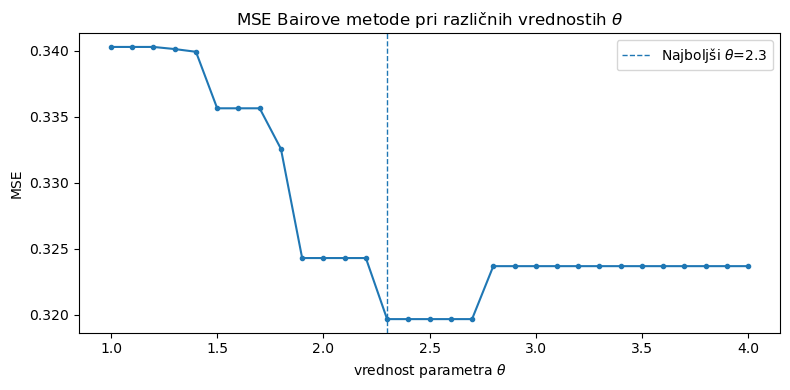

Best theta: 2.3
Best training MSE: 0.319651
Selected features at best theta: 5


In [3]:
theta_grid = np.round(np.arange(1.0, 4.0 + 1e-9, 0.1), 1)
results = []

for theta in theta_grid:
    model_t = SPCA_Bair(theta=float(theta), n_components=2)
    try:
        model_t.fit(X_train, y_train)
        mse_t = model_t.mse(X_train, y_train)
        results.append((theta, mse_t, len(model_t.selected_idx)))
    except ValueError:
        # Skip theta values that do not select enough features/components
        pass

if not results:
    raise RuntimeError("No valid theta found in the specified range.")

results = np.array(results, dtype=float)
valid_thetas = results[:, 0]
mses = results[:, 1]
selected_counts = results[:, 2].astype(int)

best_idx = np.argmin(mses)
best_theta = float(valid_thetas[best_idx])
best_mse = float(mses[best_idx])

plt.figure(figsize=(8, 4))
plt.plot(valid_thetas, mses, marker="o", markersize=3)
plt.axvline(best_theta, linestyle="--", linewidth=1, label=f"Najboljši $\\theta$={best_theta:.1f}")
plt.xlabel(f"vrednost parametra $\\theta$")
plt.ylabel("MSE")
plt.title(f"MSE Bairove metode pri različnih vrednostih $\\theta$")
plt.legend()
plt.tight_layout()
plt.savefig("../final_vizualizations/spca_bair_mse_theta.svg", format="svg", bbox_inches="tight")
plt.savefig("../final_vizualizations/spca_bair_mse_theta.png", format="png", bbox_inches="tight")
plt.show()

print(f"Best theta: {best_theta:.1f}")
print(f"Best training MSE: {best_mse:.6f}")
print(f"Selected features at best theta: {selected_counts[best_idx]}")

### Visualization of the first two supervised principal components

Best theta: 2.3
Training MSE: 0.319651
Test MSE (held-out): 0.313842


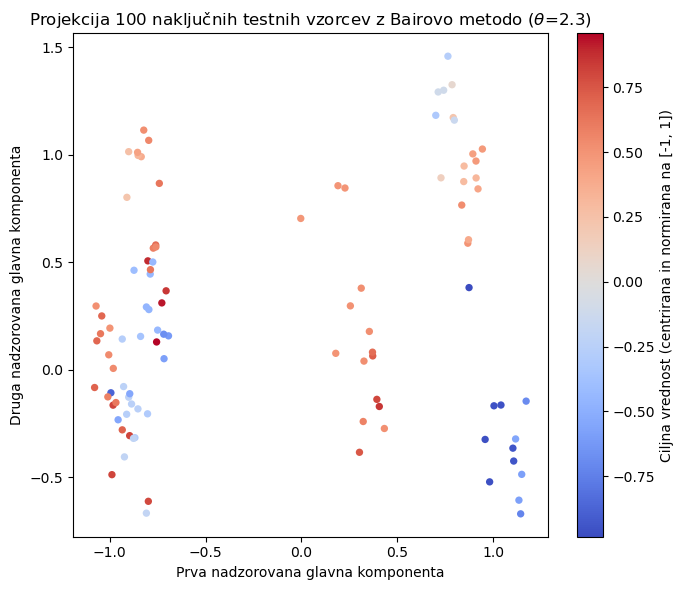

In [4]:
# Refit with best theta on the training set and evaluate on the held-out test set
model = SPCA_Bair(theta=best_theta, n_components=2)
model.fit(X_train, y_train)

train_mse = model.mse(X_train, y_train)
test_mse = model.mse(X_test, y_test)
print(f"Best theta: {best_theta:.1f}")
print(f"Training MSE: {train_mse:.6f}")
print(f"Test MSE (held-out): {test_mse:.6f}")

rng = np.random.default_rng(0)
idx = rng.choice(X_test.shape[0], size=100, replace=False)

X_s = X_test[idx]
y_s = y_test[idx]

X_theta_s = X_s[:, model.selected_idx]
proj = X_theta_s @ model.w.T  # shape: (100, 2)

plt.figure(figsize=(7, 6))
sc = plt.scatter(
    proj[:, 0],
    proj[:, 1],
    c=y_s,
    cmap="coolwarm",
    s=28,
    edgecolors="none",
)
plt.colorbar(sc, label="Ciljna vrednost (centrirana in normirana na [-1, 1])")
plt.xlabel("Prva nadzorovana glavna komponenta")
plt.ylabel("Druga nadzorovana glavna komponenta")
plt.title(f"Projekcija 100 naključnih testnih vzorcev z Bairovo metodo ($\\theta$={best_theta:.1f})")
plt.tight_layout()
plt.savefig("../final_vizualizations/spca_bair_projection.svg", format="svg", bbox_inches="tight")
plt.savefig("../final_vizualizations/spca_bair_projection.png", format="png", bbox_inches="tight")
plt.show()

The projection above uses 100 random samples from the held-out test set, so the structure shown is out-of-sample. The results show some potentially useful clusters for inferring target values. However, even though some clusters are well separated on this visualization, the datapoints don't linearly progress in target value along any of the two principal components, which means that linear regression on them will not work very well. Note also that the `theta` value was selected on the training set and the test MSE reported above is the only out-of-sample measure.

### First two supervised principal component loadings

In [5]:
# Loadings of the first two Bair principal components
W = model.w  # shape: (2, n_selected_features)
selected_feature_names = [feature_names[i] for i in model.selected_idx]

for comp_idx in range(min(2, W.shape[0])):
    print(f"\nComponent {comp_idx + 1} loadings (sorted by absolute value):")
    order = np.argsort(np.abs(W[comp_idx]))[::-1]
    for rank, j in enumerate(order, start=1):
        sign = "+" if W[comp_idx, j] >= 0 else "-"
        print(f"  {rank:>2}. {sign}{abs(W[comp_idx, j]):.4f} * {selected_feature_names[j]}")


Component 1 loadings (sorted by absolute value):
   1. -0.9487 * age
   2. +0.2929 * DFA
   3. -0.0841 * RPDE
   4. +0.0676 * test_time
   5. +0.0496 * HNR

Component 2 loadings (sorted by absolute value):
   1. -0.7007 * DFA
   2. -0.4596 * RPDE
   3. -0.3708 * test_time
   4. +0.3558 * HNR
   5. -0.1834 * age
